# Image Segmentation

<table align="left">
    <td>
        <a target="_blank" href="https://colab.research.google.com/github/thushv89/manning_tf2_in_action/blob/master/Ch08-Image-Segmentation-with-CNNs/8.1.Image_Segmentation.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
    </td>
</table>

# Chapter 8 Telling things apart: Image segmentation

shifts the focus from simple image classification to the more complex task of image segmentation. Unlike classification, which assigns a single label to an entire image, segmentation is a dense prediction task that classifies every individual pixel into a specific category. The text distinguishes between semantic segmentation, which groups pixels by object category (e.g., all persons are one class), and instance segmentation, which identifies distinct individual objects separately . The chapter utilizes the Pascal VOC 2012 dataset for this task, highlighting that target annotations are stored as palettized images—using indices mapped to a color palette—rather than standard RGB values to reduce the memory footprint.


# Downloading and extracting the data

We will be using the Pascal Voc 2012 dataset (http://host.robots.ox.ac.uk/pascal/VOC/voc2012/#data). This is a moderately complex dataset and consists of real-world scenes.

In [ ]:
# Section 8.1
# Code listing 8.1

# Downloading the data
#http://host.robots.ox.ac.uk/pascal/VOC/voc2012/#data
import os
import requests
import tarfile

# Retrieve the data
if not os.path.exists(os.path.join('data','VOCtrainval_11-May-2012.tar')):
    url = "http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar"
    # Get the file from web
    r = requests.get(url)

    if not os.path.exists('data'):
        os.mkdir('data')

    # Write to a file
    with open(os.path.join('data','VOCtrainval_11-May-2012.tar'), 'wb') as f:
        f.write(r.content)
else:
    print("The tar file already exists.")

if not os.path.exists(os.path.join('data', 'VOCtrainval_11-May-2012')):
    with tarfile.open(os.path.join('data','VOCtrainval_11-May-2012.tar'), 'r') as tar:
        tar.extractall('data')
else:
    print("The extracted data already exists")


The tar file already exists.
The extracted data already exists


## Load and visualize a single annotated image

For each data point, there are two images.
* Original input image - Represents a scene with some objects
* Target segmented image - Represents the annotated segments of the images

The segmented image is stored as a *palletted version* in order to reduce the memory footprint. This means that the image stores a special attribute called *pallette*. Then you have to perform some transformations in order to get the actual RGB values. The details of this process are discussed in the book.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


The format of the data JPEG
This image is of size: (375, 500, 3)
The annotated image is of size: (375, 500)


(-0.5, 499.5, 374.5, -0.5)

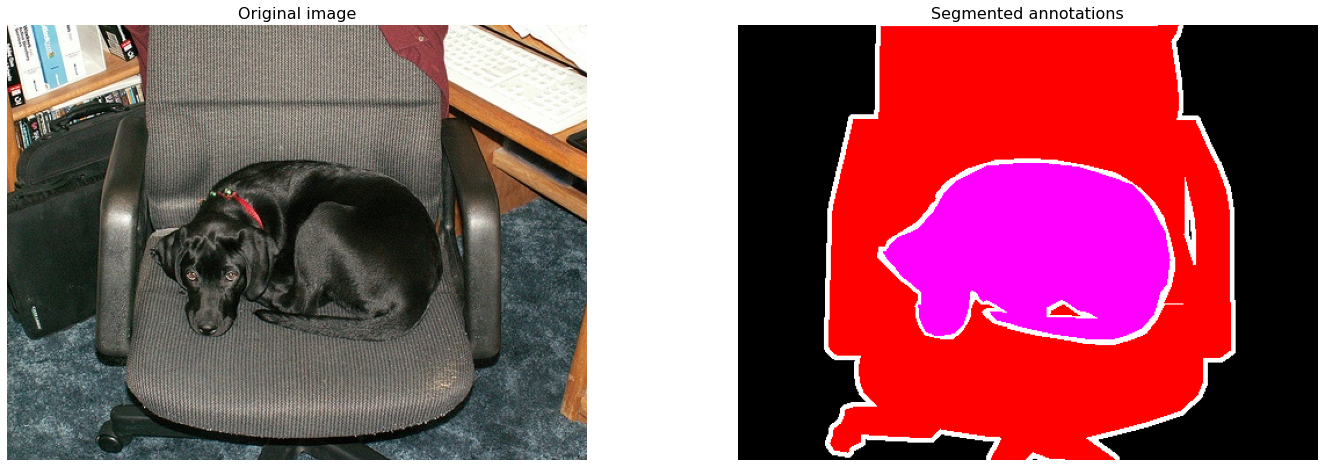

In [ ]:
# Section 8.1

orig_image_path = os.path.join('data', 'VOCtrainval_11-May-2012', 'VOCdevkit', 'VOC2012', 'JPEGImages', '2007_000063.jpg')
annot_image_path = os.path.join('data', 'VOCtrainval_11-May-2012', 'VOCdevkit', 'VOC2012', 'SegmentationClass', '2007_000063.png')

orig_image = Image.open(orig_image_path)
print("The format of the data {}".format(orig_image.format))
orig_image = np.array(orig_image)
print("This image is of size: {}".format(orig_image.shape))

annot_image = Image.open(annot_image_path)
print("The annotated image is of size: {}".format(np.array(annot_image).shape))

# Code listing 8.2
def rgb_image_from_pallette(image):
    """ This function restores the RGB values form a palletted PNG image """
    pallette = annot_image.getpalette()
    # Convert the pallet to a sequence of RGB values (n, 3) shape
    pallette = np.array(pallette).reshape(-1,3)
    if isinstance(image, PngImageFile):
        h, w = image.height, image.width
        # Squash height and width dimensions (makes slicing easier)
        image = np.array(image).reshape(-1)
    elif isinstance(image, np.ndarray):
        h, w = image.shape[0], image.shape[1]
        image = image.reshape(-1)

    rgb_image = np.zeros(shape=(image.shape[0],3))

    # For all locations where image value is not zero,
    # we replace those locations in the RGB image with the corresponding values from the pallette
    rgb_image[(image != 0),:] = pallette[image[(image != 0)], :]
    rgb_image = rgb_image.reshape(h, w, 3)

    return rgb_image


annot_rgb_image = rgb_image_from_pallette(annot_image)

plt.subplots(1,2, figsize=(24,8))
plt.subplot(1,2,1)
plt.imshow(orig_image)
plt.title("Original image", fontsize=16)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(annot_rgb_image)
plt.title("Segmented annotations", fontsize=16)
plt.axis('off')


# Different Classes present in the data

The dataset consists of following classes. Each pixel in every target image is annotated with one of the below classes.

* 0 - Background
* 1 - Aeroplane
* 2 - Bicycle
* 3 - Bird
* 4 - Boat
* 5 - Bottel
* 6 - Bus
* 7 - Car
* 8 - Cat
* 9 - Chair
* 10 - Cow
* 11 - Dining table
* 12 - Dog
* 13 - Horse
* 14 - Motorbike
* 15 - Person
* 16 - Potted plant
* 17 - Sheep
* 18 - Sofa
* 19 - Train
* 20 - TV/Monitor
* 255 - Boundaries / Unknown object


# Defining the input data pipeline with `tf.data`

To handle this data efficiently, the chapter details the construction of a scalable tf.data pipeline. This pipeline employs a custom NumPy function to load palettized images directly, preventing unwanted conversion to RGB which would corrupt the class labels . The preprocessing strategy involves resizing images to a larger dimension and then randomly cropping them to a fixed input size . A critical distinction is made in interpolation methods: bilinear interpolation is used for input images to smooth pixel values, while nearest-neighbor interpolation is strictly used for target masks to preserve integer class labels . The pipeline also incorporates data augmentation techniques, such as horizontal flipping and contrast adjustments, and utilizes optimization methods like caching and prefetching to minimize model idling during training .

Let's setup a `tf.data` pipeline to get the data from the disk to our model. In this the pipeline will perform steps such as,

* Read the image files from list of filenames
* Normalize the images
* Randomly crop (during augmentation) or resize (no augmentation) images so that all images are the same size
* Various random augmentations (translations/hue/brightness/saturation)
* Batch data

If you don't have step 3 and try to batch data, you will get the error,

```
InvalidArgumentError: Cannot batch tensors with different shapes in component 0. First element had shape [375,500,3] and element 1 had shape [333,500,3]. [Op:IteratorGetNext]
```

## Pipeline optimizations

* Without optimization - 477 ms per step
* With prefetching - 444ms per step
* With caching
    * Memory monotinically increasing memory from 5.2G -> 6.89G
    * Time 450ms per step

In [ ]:
# Section 8.2

# Code listing 8.3
def get_subset_filenames(orig_dir, seg_dir, subset_dir, subset):
    """ Get the filenames for a given subset (train/valid/test)"""
    if subset.startswith('train'):
        ser = pd.read_csv(os.path.join(subset_dir, "train.txt"), index_col=None, header=None, squeeze=True).tolist()
    elif subset.startswith('val') or subset.startswith('test'):
        # Fix the random seed to make sure we get consistent results
        random.seed(random_seed)
        # Read the filenames from the file
        ser = pd.read_csv(os.path.join(subset_dir, "val.txt"), index_col=None, header=None, squeeze=True).tolist()
        # Shuffle the data
        random.shuffle(ser)
        # The first half will be considred as validation data and
        # the second as the test data
        if subset.startswith('val'):
            ser = ser[:len(ser)//2]
        else:
            ser = ser[len(ser)//2:]
    else:
        raise NotImplementedError("Subset={} is not recognized".format(subset))

    # Generate two lists one for input images, one for target images
    orig_filenames = [os.path.join(orig_dir,f+'.jpg') for f in ser]
    seg_filenames = [os.path.join(seg_dir, f+'.png') for f in ser]

    # Return a generator that returns an input image and a segmentation image
    for o, s in zip(orig_filenames, seg_filenames):
        yield o, s


def load_image_func(image):
    """ Load the image given a filename """

    img =  np.array(Image.open(image))
    return img



def fix_shape(x, y, target_size):
    """ Set the shape of the input/target tensors """

    x.set_shape((target_size[0], target_size[1], 3))
    y.set_shape((target_size[0], target_size[1], 1))

    return x, y

# Code listing 8.5
def randomly_flip_horizontal(x, y):
    """ Randomly flip images horizontally. Remember that any transformation
    must be performed for both input/target consistently """

    rand = tf.random.uniform([], 0.0,1.0)

    def flip(x, y):
        return tf.image.flip_left_right(x), tf.image.flip_left_right(y)

    x, y = tf.cond(rand < 0.5, lambda: flip(x, y), lambda: (x, y))

    return x, y

def randomly_translate(x, y):
    """ Randomly translate images """

    tx, ty = tf.random.uniform([],-50, 50),  tf.random.uniform([], -50, 50)

    x, y = tfa.image.translate(x, [tx, ty]), tfa.image.translate(y, [tx, ty])
    return x, y

# Code listing 8.6
def get_subset_tf_dataset(
    subset_filename_gen_func, batch_size, epochs,
    input_size=(256, 256), output_size=None, resize_to_before_crop=None,
    augmentation=False, shuffle=False
):

    # Safety check to make sure that resize_to_before_crop is defined whenever user wants to
    # augment data
    if augmentation and not resize_to_before_crop:
        raise RuntimeError("You must define resize_to_before_crop when augmentation is enabled.")

    # Return a list of filenames, depending on the training/validation/test subset requested
    filename_ds = tf.data.Dataset.from_generator(
        subset_filename_gen_func, output_types=(tf.string, tf.string)
    )

    # Load the images from the filenames returned by the above step
    image_ds = filename_ds.map(lambda x,y: (
        tf.image.decode_jpeg(tf.io.read_file(x)),
        tf.numpy_function(load_image_func, [y], [tf.uint8])
    )).cache()

    image_ds = image_ds.map(lambda x, y: (tf.cast(x, 'float32')/255.0, y))

    # Code listing 8.4
    def randomly_crop_or_resize(x,y):
        """ Randomly crops or resizes the images """

        rand = tf.random.uniform([], 0.0,1.0)

        def rand_crop(x, y):
            """ Randomly crop images after enlarging them """
            x = tf.image.resize(x, resize_to_before_crop, method='bilinear')
            y = tf.cast(tf.image.resize(tf.transpose(y,[1,2,0]), resize_to_before_crop, method='nearest'),'float32')

            offset_h = tf.random.uniform([], 0, x.shape[0]-input_size[0], dtype='int32')
            offset_w = tf.random.uniform([], 0, x.shape[1]-input_size[1], dtype='int32')
            x = tf.image.crop_to_bounding_box(x, offset_h, offset_w, input_size[0], input_size[1])
            y = tf.image.crop_to_bounding_box(y, offset_h, offset_w, input_size[0], input_size[1])

            return x, y

        def resize(x, y):
            """ Resize images to a desired size """
            x = tf.image.resize(x, input_size, method='bilinear')
            y = tf.cast(tf.image.resize(tf.transpose(y,[1,2,0]), input_size, method='nearest'),'float32')

            return x, y

        if augmentation and (input_size[0]< resize_to_before_crop[0] or input_size[1]< resize_to_before_crop[1]):
            x, y = tf.cond(
                rand < 0.5,
                lambda: rand_crop(x, y),
                lambda: resize(x, y)
            )
        else:
            x, y = resize(x, y)

        return x, y

    # This is an important step. Basically if you want to batch data, they should have the same shape
    image_ds = image_ds.map(lambda x,y: randomly_crop_or_resize(x,y))
    image_ds = image_ds.map(lambda x,y: fix_shape(x,y, target_size=input_size))

    # Code listing 8.5
    # If augmentations are requested
    if augmentation:
        # Randomly flip horizontally
        image_ds = image_ds.map(lambda x, y: randomly_flip_horizontal(x,y))
        # Randomly adjust hue
        image_ds = image_ds.map(lambda x, y: (tf.image.random_hue(x, 0.1), y))
        # Randomly adjust brightness
        image_ds = image_ds.map(lambda x, y: (tf.image.random_brightness(x, 0.1), y))
        # Randomly adjust contrast
        image_ds = image_ds.map(lambda x, y: (tf.image.random_contrast(x, 0.8, 1.2), y))

    if output_size:
        image_ds = image_ds.map(lambda x, y: (x, tf.image.resize(y, output_size, method='nearest')))

    # Shuffle the data
    if shuffle:
        image_ds = image_ds.shuffle(buffer_size=batch_size*5)

    # Batch the data and repeat it for the desired number of epochs
    image_ds = image_ds.batch(batch_size).repeat(epochs)


    image_ds = image_ds.prefetch(tf.data.experimental.AUTOTUNE)

    # Remove any dimensions of size 1 from the target
    image_ds = image_ds.map(lambda x, y: (x, tf.squeeze(y)))

    return image_ds

# Code listing 8.7

orig_dir = os.path.join('data', 'VOCtrainval_11-May-2012', 'VOCdevkit', 'VOC2012', 'JPEGImages')
seg_dir = os.path.join('data', 'VOCtrainval_11-May-2012', 'VOCdevkit', 'VOC2012', 'SegmentationClass')
subset_dir = os.path.join('data', 'VOCtrainval_11-May-2012', 'VOCdevkit', 'VOC2012', 'ImageSets', "Segmentation")

# Define a partial function of get_subset_filenames
partial_subset_fn = partial(get_subset_filenames, orig_dir=orig_dir, seg_dir=seg_dir, subset_dir=subset_dir)
# Use training subset
train_subset_fn = partial(partial_subset_fn, subset='train')
# Use validation subset
val_subset_fn = partial(partial_subset_fn, subset='val')
# Use testing subset
test_subset_fn = partial(partial_subset_fn, subset='test')

# Define a train and validation dataset
tr_image_ds = get_subset_tf_dataset(train_subset_fn, 2, 1, shuffle=True)
val_image_ds = get_subset_tf_dataset(val_subset_fn, 2, 1, shuffle=False)

# Get the data specifications out
print(tf.data.DatasetSpec.from_value(tr_image_ds))

# Iterate 2 elements of each dataset
for i, j in tr_image_ds.take(2):
    print("Input: {}, Target: {}".format(i.shape, j.shape))
    print(tf.reduce_max(j))

for i, j in val_image_ds.take(2):
    print("Input: {}, Target: {}".format(i.shape, j.shape))

2026-01-08 21:42:44.662178: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-08 21:42:44.662870: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-01-08 21:42:44.663315: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-01-08 21:42:44.663669: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zer

DatasetSpec((TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=<unknown>, dtype=tf.float32, name=None)), TensorShape([]))
Input: (2, 256, 256, 3), Target: (2, 256, 256)
tf.Tensor(255.0, shape=(), dtype=float32)
Input: (2, 256, 256, 3), Target: (2, 256, 256)
tf.Tensor(255.0, shape=(), dtype=float32)
Input: (2, 256, 256, 3), Target: (2, 256, 256)
Input: (2, 256, 256, 3), Target: (2, 256, 256)


/tmp/ipykernel_8461/2128876438.py:7: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  ser = pd.read_csv(os.path.join(subset_dir, "train.txt"), index_col=None, header=None, squeeze=True).tolist()
2026-01-08 21:42:45.669442: W tensorflow/core/kernels/data/cache_dataset_ops.cc:856] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
/tmp/ipykernel_8461/2128876438.py:12: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  ser = pd.read_csv(os.path.join(subset_dir, "val.txt"), index_col=None, header=None, sque

# Plot the data from the tf.data pipeline

/tmp/ipykernel_8461/2128876438.py:7: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  ser = pd.read_csv(os.path.join(subset_dir, "train.txt"), index_col=None, header=None, squeeze=True).tolist()
2026-01-08 21:42:49.518325: W tensorflow/core/kernels/data/cache_dataset_ops.cc:856] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


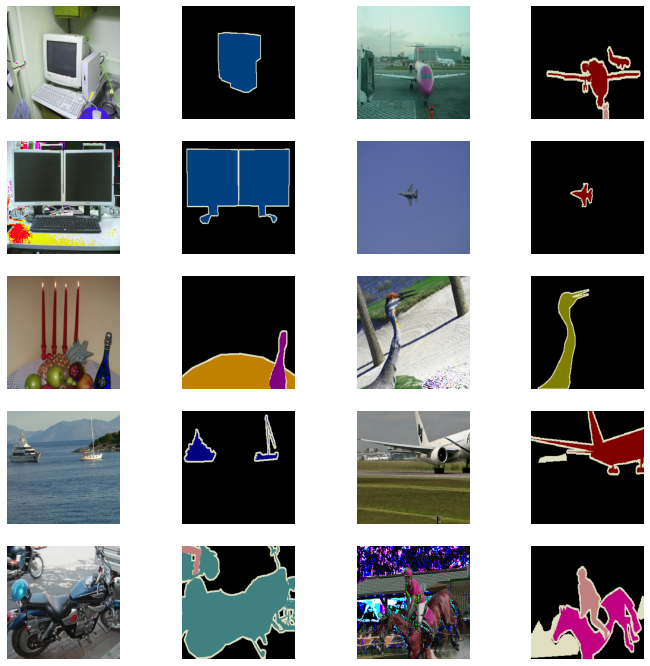

In [ ]:
# Definin an instance of the training tf.data pipeline
tr_image_ds = get_subset_tf_dataset(
    train_subset_fn, 1, 1, augmentation=True, resize_to_before_crop=(384,384), shuffle=True)
n=10

def plot_data(image_ds, n):
    """ Plot n images from a given tf.data pipeline"""

    # Defining the figure
    plt.subplots(n//2, 4, figsize=(12,12))

    for i, (img, y_true) in enumerate(tr_image_ds.take(n)):

        # Getting the RGB version of the palettized image
        y_true = y_true.numpy().astype('int')
        y_rgb_true = rgb_image_from_pallette(y_true)

        # Plot the original image
        plt.subplot(n//2,4,i*2+1)
        plt.imshow((img[0,:, :, :].numpy()*255.0).astype('uint8'))
        plt.axis('off')

        # Plot the target image
        plt.subplot(n//2,4, i*2+2)
        plt.imshow(y_rgb_true.astype('uint8'))
        plt.axis('off')

plot_data(tr_image_ds, n)

## Visualizing a sample for all classes

/tmp/ipykernel_8461/2128876438.py:7: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  ser = pd.read_csv(os.path.join(subset_dir, "train.txt"), index_col=None, header=None, squeeze=True).tolist()
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for

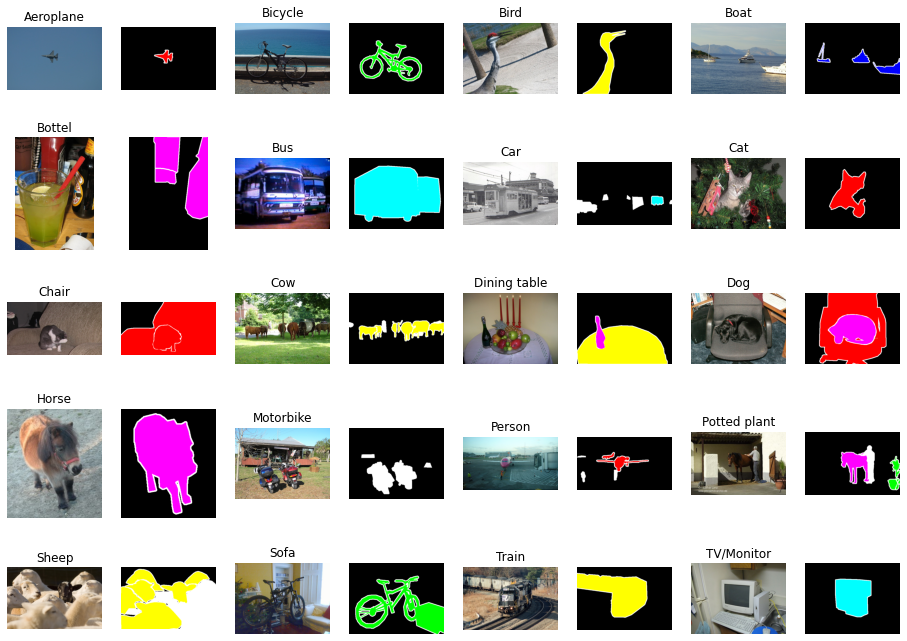

In [ ]:
orig_dir = os.path.join('data', 'VOCtrainval_11-May-2012', 'VOCdevkit', 'VOC2012', 'JPEGImages')
seg_dir = os.path.join('data', 'VOCtrainval_11-May-2012', 'VOCdevkit', 'VOC2012', 'SegmentationClass')
subset_dir = os.path.join('data', 'VOCtrainval_11-May-2012', 'VOCdevkit', 'VOC2012', 'ImageSets', "Segmentation")

# Getting the train filename generator
train_fn_gen = get_subset_filenames(orig_dir, seg_dir, subset_dir, 'training')

plot_images = {}

# Defining the class label to class name mapping
classes = {
    0: "Background", 1: "Aeroplane", 2 : "Bicycle", 3: "Bird", 4: "Boat", 5: "Bottel",
    6: "Bus", 7: "Car", 8: "Cat", 9: "Chair", 10: "Cow", 11: "Dining table",
    12: "Dog", 13: "Horse", 14: "Motorbike", 15: "Person", 16: "Potted plant", 17: "Sheep",
    18: "Sofa", 19: "Train", 20: "TV/Monitor", 255: "Boundaries / Unknown object"
}

# Train filename generator generates an input image and a target image every iteration
for input_path, target_path in train_fn_gen:

    # Load the input image
    input_img =  np.array(Image.open(input_path))
    # Load the target image
    target_img =  np.array(Image.open(target_path))

    # Find out the class that has the largest representation (except classes 0 or 255)
    largest_cls = np.max(target_img[(target_img != 0) & (target_img != 255)])

    # If we haven't seen an image having the class before, we will add it to plot_images
    if largest_cls not in plot_images:
        plot_images[largest_cls] = (input_img, target_img)

    # Once we collect images for all classes, break
    if len(plot_images)>=20:
        break

# Plot the collected images
plt.subplots(5,8, figsize=(16,12))

for i, (k, v) in enumerate(sorted(plot_images.items(), key=lambda x: x[0])):

    input_img, target_img = v

    target_img = rgb_image_from_pallette(target_img)

    # Plot input image
    plt.subplot(5,8,(i*2)+1)
    plt.imshow(input_img)
    plt.title("{}".format(classes[i+1]))
    plt.axis('off')

    # Plot target image
    plt.subplot(5,8,(i*2)+2)
    plt.imshow(target_img)
    plt.axis('off')


## DeepLabv3: Using pretrained networks to segment images

The architectural focus of the chapter is the implementation of the DeepLab v3 model, designed to overcome the "representational bottleneck" found in standard Convolutional Neural Networks (CNNs). Standard CNNs typically reduce image resolution significantly through pooling and striding, which is detrimental for segmentation . DeepLab v3 addresses this by using a pretrained ResNet-50 backbone modified with atrous (or dilated) convolution, which inserts zeros between kernel weights to expand the receptive field without reducing spatial resolution . The model’s core innovation is the Atrous Spatial Pyramid Pooling (ASPP) module, which captures image features at multiple scales by running parallel convolutions with different dilation rates .

## Defining the tf.data pipeline for DeepLab v3 model

In [ ]:
batch_size = 8
epochs = 25

def get_steps_per_epoch(n_data, batch_size):
    """ Get steps for single epoch """
    if n_data % batch_size == 0:
        return n_data//batch_size
    else:
        return (n_data//batch_size)+1

# Defining training/validation steps for training / validation phases
n_train = get_steps_per_epoch(
    len(pd.read_csv(os.path.join(subset_dir, "train.txt"), index_col=None, header=None, squeeze=True).tolist()),
    batch_size
)
n_valid = get_steps_per_epoch(
    len(pd.read_csv(os.path.join(subset_dir, "val.txt"), index_col=None, header=None, squeeze=True).tolist())//2,
    batch_size
)

input_size = (384, 384)

# Defining train/valid/test data pipelines
tr_image_ds = get_subset_tf_dataset(
    train_subset_fn, batch_size, epochs,
    input_size=input_size, resize_to_before_crop=(444,444),
    augmentation=True, shuffle=True
)
val_image_ds = get_subset_tf_dataset(
    val_subset_fn, batch_size, epochs,
    input_size=input_size,
    shuffle=False)
test_image_ds = get_subset_tf_dataset(
    test_subset_fn, batch_size, 1,
    input_size=input_size,
    shuffle=False)

/tmp/ipykernel_8461/3212776037.py:13: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  len(pd.read_csv(os.path.join(subset_dir, "train.txt"), index_col=None, header=None, squeeze=True).tolist()),
/tmp/ipykernel_8461/3212776037.py:17: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  len(pd.read_csv(os.path.join(subset_dir, "val.txt"), index_col=None, header=None, squeeze=True).tolist())//2,


In [ ]:
# Section 8.3

K.clear_session()

num_classes = 21


# Reference implementation
# https://github.com/rishizek/tensorflow-deeplab-v3/blob/master/deeplab_model.py
def get_deeplabv3(target_size):

    # Code listing 8.8
    def block_level3(inp, filters, kernel_size, rate, block_id, convlayer_id, activation=True):
        """ A single conv layer subblock in a resnet block with atrous convolution """
        conv5_block_conv_out = layers.Conv2D(
            filters, kernel_size, dilation_rate=rate, padding='same', name='conv5_block{}_{}_conv'.format(block_id, convlayer_id)
        )(inp)
        conv5_block_bn_out = layers.BatchNormalization(
            name='conv5_block{}_{}_bn'.format(block_id, convlayer_id)
        )(conv5_block_conv_out)

        if activation:
            conv5_block_relu_out = layers.Activation(
                'relu', name='conv5_block{}_{}_relu'.format(block_id, convlayer_id)
            )(conv5_block_bn_out)
            return conv5_block_relu_out
        else:
            return conv5_block_bn_out

    # Code listing 8.9
    def block_level2(inp, rate, block_id):
        block_1_out = block_level3(inp, 512, (1,1), rate, block_id, 1)
        block_2_out = block_level3(block_1_out, 512, (3,3), rate, block_id, 2)
        block_3_out = block_level3(block_2_out, 2048, (1,1), rate, block_id, 3, activation=False)

        return block_3_out

    # Code listing 8.10
    def resnet_block(inp, rate):
        """ Redefining a resnet block with atrous convolution """

        # Block 4 with atrous rate = 2
        block0_out = block_level3(inp, 2048, (1,1), 1, block_id=1, convlayer_id=0, activation=False)
        block1_out = block_level2(inp, 2, block_id=1)
        block1_add = layers.Add(name='conv5_block{}_add'.format(1))([block0_out, block1_out])
        block1_relu = layers.Activation('relu', name='conv5_block{}_relu'.format(1))(block1_add)

        block2_out = block_level2(block1_relu, 2, block_id=2) # no relu
        block2_add = layers.Add(name='conv5_block{}_add'.format(2))([block1_add, block2_out])
        block2_relu = layers.Activation('relu', name='conv5_block{}_relu'.format(2))(block2_add)

        block3_out = block_level2(block2_relu, 2, block_id=3)
        block3_add = layers.Add(name='conv5_block{}_add'.format(3))([block2_add, block3_out])
        block3_relu = layers.Activation('relu', name='conv5_block{}_relu'.format(3))(block3_add)

        return block3_relu

    # Code listing 8.11
    def atrous_spatial_pyramid_pooling(inp):
        """ Defining the ASPP (Atrous spatial pyramid pooling) module """

        # Part A: 1x1 and atrous convolutions
        outa_1_conv = block_level3(inp, 256, (1,1), 1, '_aspp_a', 1, activation='relu')
        outa_2_conv = block_level3(inp, 256, (3,3), 6, '_aspp_a', 2, activation='relu')
        outa_3_conv = block_level3(inp, 256, (3,3), 12, '_aspp_a', 3, activation='relu')
        outa_4_conv = block_level3(inp, 256, (3,3), 18, '_aspp_a', 4, activation='relu')

        # Part B: global pooling
        # This is then bilineared ( is that needed? to match size - yes)
        outb_1_avg = layers.Lambda(lambda x: K.mean(x, axis=[1,2], keepdims=True))(inp)
        outb_1_conv = block_level3(outb_1_avg, 256, (1,1), 1, '_aspp_b', 1, activation='relu')
        outb_1_up = layers.UpSampling2D((24,24), interpolation='bilinear')(outb_1_avg)
        out_aspp = layers.Concatenate()([outa_1_conv, outa_2_conv, outa_3_conv, outa_4_conv, outb_1_up])

        return out_aspp

    # Code listing 8.12

    # Pretrained model and the input
    inp = layers.Input(shape=target_size+(3,))
    resnet50 = tf.keras.applications.ResNet50(
        include_top=False, input_tensor=inp,pooling=None
    )

    # We will need to modify the network beyond this layer
    # Therefore defining a model upto that point
    for layer in resnet50.layers:
        if layer.name == "conv5_block1_1_conv":
            break
        out = layer.output

    resnet50_upto_conv4 = models.Model(resnet50.input, out)

    # Adding the newly defined resnet block with atrous convolution
    resnet_block4_out = resnet_block(resnet50_upto_conv4.output, 2)
    # Adding the ASPP module
    out_aspp = atrous_spatial_pyramid_pooling(resnet_block4_out)

    final_out = layers.Conv2D(21, (1,1), padding='same')(out_aspp)
    final_out = layers.UpSampling2D((16,16), interpolation='bilinear')(final_out)

    # Defining the final module
    deeplabv3 = models.Model(resnet50_upto_conv4.input, final_out)

    # We need to re-set the weights of the removed layers after compiling the model
    # For that we will store the weights in a dictionary for later use
    w_dict = {}
    for l in ["conv5_block1_0_conv", "conv5_block1_0_bn",
              "conv5_block1_1_conv", "conv5_block1_1_bn",
              "conv5_block1_2_conv", "conv5_block1_2_bn",
              "conv5_block1_3_conv", "conv5_block1_3_bn"]:
        w_dict[l] = resnet50.get_layer(l).get_weights()

    return deeplabv3, w_dict

# Defining the model
deeplabv3, w_dict = get_deeplabv3(input_size)

## Compiling the model: Loss functions and evaluation metrics in image segmentation

The chapter addresses the challenge of class imbalance, where background pixels vastly outnumber object pixels, by defining specialized loss functions and evaluation metrics. The model is trained using a combined loss function consisting of weighted categorical cross-entropy—which assigns higher weights to rarer classes—and dice loss, which maximizes the overlap between predicted and true masks . Performance is measured using Pixel Accuracy, Mean Accuracy, and the industry-standard Mean Intersection over Union (Mean IoU) .

# Define losses

Here we will be defining 3 different losses
 * dice loss
 * cross entropy loss
 * dice loss + cross entropy loss

In [ ]:
# Section 8.4

num_classes = 21 # Ignore the 255 (boundary / unknown object class)

# Code listing 8.13
def get_label_weights(y_true, y_pred):
    """ Get label weights """

    # Get pixel sum over width and height -> [b, classes]
    # where each element represents how many pixels of that class in that input image
    weights = tf.reduce_sum(tf.one_hot(y_true, num_classes), axis=[1,2]) # [b, classes]

    # Get pixel sum for each image -> [b, 1]
    tot = tf.reduce_sum(weights, axis=-1, keepdims=True)

    # More frequent pixels get smaller weight and rare ones get larger weights
    weights = (tot - weights) / tot # [b, classes]

    # Turn y_true to a [b, -1] sized output
    y_true = tf.reshape(y_true, [-1, y_pred.shape[1]*y_pred.shape[2]]) #[b, -1]

    # For each annotated pixel, get the associated weight from the weight vector
    y_weights = tf.gather(weights, y_true, batch_dims=1)
    y_weights = tf.reshape(y_weights, [-1])

    # return weights
    return y_weights

# Code listing 8.15
def dice_loss_from_logits(num_classes):
    """ Defining the dice loss 1 - [(2* i + 1)/(u + i)]"""

    def loss_fn(y_true, y_pred):

        smooth = 1.

        # Convert y_true to int and set shape
        y_true = tf.cast(y_true, 'int32')
        y_true.set_shape([None, y_pred.shape[1], y_pred.shape[2]])

        # Get pixel weights
        y_weights = tf.reshape(get_label_weights(y_true, y_pred), [-1, 1])

        # Apply softmax to logits
        y_pred = tf.nn.softmax(y_pred)

        # Unwrap both y_true and y_pred on width and height dimensions
        # y_true -> [b*h*w]
        # y_pred -> [b*h*w, 22]

        y_true_unwrap = tf.reshape(y_true, [-1])
        # Any label having a higher value than the depth we defined, is ignored
        y_true_unwrap = tf.cast(tf.one_hot(tf.cast(y_true_unwrap, 'int32'), num_classes), 'float32')
        y_pred_unwrap = tf.reshape(y_pred, [-1, num_classes])

        # Intersection is taken by multiplying y_true_unwrap * y_pred_unwrap * weights
        intersection = tf.reduce_sum(y_true_unwrap * y_pred_unwrap * y_weights)
        # Union is the sum of y_true_unwrap and y_pred_unwrap
        union = tf.reduce_sum((y_true_unwrap + y_pred_unwrap) * y_weights)

        # compute the dice coefficient
        score = (2. * intersection + smooth) / ( union + smooth)

        # Compute the loss
        loss = 1 - score

        return loss

    return loss_fn

# Code listing 8.14
def ce_weighted_from_logits(num_classes):

    def loss_fn(y_true, y_pred):
        """ Defining cross entropy weighted loss """

        # We are going to ignore the 255-label class
        valid_mask = tf.cast(tf.reshape((y_true <= num_classes - 1), [-1,1]), 'int32')

        y_true = tf.cast(y_true, 'int32')
        y_true.set_shape([None, y_pred.shape[1], y_pred.shape[2]])

        y_weights = get_label_weights(y_true, y_pred)
        y_pred_unwrap = tf.reshape(y_pred, [-1, num_classes])
        y_true_unwrap = tf.reshape(y_true, [-1])

        return tf.reduce_mean(
            y_weights * tf.nn.sparse_softmax_cross_entropy_with_logits(
                y_true_unwrap * tf.squeeze(valid_mask),
                y_pred_unwrap * tf.cast(valid_mask, 'float32'))
        )

    return loss_fn

# Code listing 8.16
def ce_dice_loss_from_logits(num_classes):

    def loss_fn(y_true, y_pred):
        # Sum of cross entropy and dice losses
        loss = ce_weighted_from_logits(num_classes)(tf.cast(y_true, 'int32'), y_pred) + \
            dice_loss_from_logits(num_classes)(y_true, y_pred)

        return loss

    return loss_fn


# Define Metrics

Here we will be defining three different metrics
* Mean IoU
* Mean accuracy
* Pixel accuracy

In [ ]:
# Section 8.4

# Code listing 8.17
class PixelAccuracyMetric(tf.keras.metrics.Accuracy):

  def __init__(self, num_classes, name='pixel_accuracy', **kwargs):
    super(PixelAccuracyMetric, self).__init__(name=name, **kwargs)

  def update_state(self, y_true, y_pred, sample_weight=None):

    y_true.set_shape([None, y_pred.shape[1], y_pred.shape[2]])
    y_true = tf.reshape(y_true, [-1])

    y_pred = tf.reshape(tf.argmax(y_pred, axis=-1),[-1])

    valid_mask = tf.reshape((y_true <= num_classes - 1), [-1])

    # Get pixels corresponding to valid mask
    y_true = tf.boolean_mask(y_true, valid_mask)
    y_pred = tf.boolean_mask(y_pred, valid_mask)

    super(PixelAccuracyMetric, self).update_state(y_true, y_pred)


# Code listing 8.18
class MeanAccuracyMetric(tf.keras.metrics.Mean):

  def __init__(self, num_classes, name='mean_accuracy', **kwargs):
    super(MeanAccuracyMetric, self).__init__(name=name, **kwargs)

  def update_state(self, y_true, y_pred, sample_weight=None):

    smooth = 1

    y_true.set_shape([None, y_pred.shape[1], y_pred.shape[2]])

    # Unwrap y_true y_pred
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(tf.argmax(y_pred, axis=-1),[-1])

    valid_mask = tf.reshape((y_true <= num_classes - 1), [-1])

    y_true = tf.boolean_mask(y_true, valid_mask)
    y_pred = tf.boolean_mask(y_pred, valid_mask)

    # sum on axis=0 > prediction counts
    # sum on axis=1 > actual counts
    conf_matrix = tf.cast(tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes), 'float32')
    true_pos = tf.linalg.diag_part(conf_matrix)

    # Add a smooth constant in case denominator is zero
    mean_accuracy = tf.reduce_mean(
        (true_pos + smooth)/(tf.reduce_sum(conf_matrix, axis=1) + smooth)
    )

    super(MeanAccuracyMetric, self).update_state(mean_accuracy)


# Code listing 8.19
class MeanIoUMetric(tf.keras.metrics.MeanIoU):

  def __init__(self, num_classes, name='mean_iou', **kwargs):
    super(MeanIoUMetric, self).__init__(num_classes=num_classes, name=name, **kwargs)

  def update_state(self, y_true, y_pred, sample_weight=None):

    y_true.set_shape([None, y_pred.shape[1], y_pred.shape[2]])
    y_true = tf.reshape(y_true, [-1])

    y_pred = tf.nn.softmax(y_pred)
    y_pred = tf.reshape(tf.argmax(y_pred, axis=-1),[-1])

    valid_mask = tf.reshape((y_true <= num_classes - 1), [-1])

    # Get pixels corresponding to valid mask
    y_true = tf.boolean_mask(y_true, valid_mask)
    y_pred = tf.boolean_mask(y_pred, valid_mask)

    super(MeanIoUMetric, self).update_state(y_true, y_pred)


## Compiling the model

In [ ]:
# Compiling the model
optimizer = tf.keras.optimizers.Adam(lr=0.0001)
deeplabv3.compile(
    loss=ce_dice_loss_from_logits(num_classes),
    optimizer=optimizer,
    metrics=[
        MeanIoUMetric(num_classes),
        MeanAccuracyMetric(num_classes),
        PixelAccuracyMetric(num_classes)
    ])

# Setting weights for newly added layers
for k, w in w_dict.items():
    deeplabv3.get_layer(k).set_weights(w)

deeplabv3.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 384, 384, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 390, 390, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 192, 192, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                            

                                                                                                  
 conv2_block3_1_relu (Activatio  (None, 96, 96, 64)  0           ['conv2_block3_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_2_conv (Conv2D)   (None, 96, 96, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 96, 96, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 96, 96, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)       

                                                                                                  
 conv3_block3_1_relu (Activatio  (None, 48, 48, 128)  0          ['conv3_block3_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_2_conv (Conv2D)   (None, 48, 48, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 48, 48, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 48, 48, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)       

                                                                                                  
 conv4_block2_1_bn (BatchNormal  (None, 24, 24, 256)  1024       ['conv4_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_1_relu (Activatio  (None, 24, 24, 256)  0          ['conv4_block2_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_2_conv (Conv2D)   (None, 24, 24, 256)  590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 24, 24, 256)  1024       ['conv4_block2_2_conv[0][0]']    
 ization) 

 conv4_block5_1_conv (Conv2D)   (None, 24, 24, 256)  262400      ['conv4_block4_out[0][0]']       
                                                                                                  
 conv4_block5_1_bn (BatchNormal  (None, 24, 24, 256)  1024       ['conv4_block5_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_1_relu (Activatio  (None, 24, 24, 256)  0          ['conv4_block5_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_2_conv (Conv2D)   (None, 24, 24, 256)  590080      ['conv4_block5_1_relu[0][0]']    
                                                                                                  
 conv4_blo

                                                                                                  
 conv5_block1_add (Add)         (None, 24, 24, 2048  0           ['conv5_block1_0_bn[0][0]',      
                                )                                 'conv5_block1_3_bn[0][0]']      
                                                                                                  
 conv5_block1_relu (Activation)  (None, 24, 24, 2048  0          ['conv5_block1_add[0][0]']       
                                )                                                                 
                                                                                                  
 conv5_block2_1_conv (Conv2D)   (None, 24, 24, 512)  1049088     ['conv5_block1_relu[0][0]']      
                                                                                                  
 conv5_block2_1_bn (BatchNormal  (None, 24, 24, 512)  2048       ['conv5_block2_1_conv[0][0]']    
 ization) 

/home/thushv89/anaconda3/envs/manning.tf2.9/lib/python3.9/site-packages/keras/optimizers/optimizer_v2/adam.py:110: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


                                )                                                                 
                                                                                                  
 conv5_block3_1_conv (Conv2D)   (None, 24, 24, 512)  1049088     ['conv5_block2_relu[0][0]']      
                                                                                                  
 conv5_block3_1_bn (BatchNormal  (None, 24, 24, 512)  2048       ['conv5_block3_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block3_1_relu (Activatio  (None, 24, 24, 512)  0          ['conv5_block3_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv5_blo

 up_sampling2d_1 (UpSampling2D)  (None, 384, 384, 21  0          ['conv2d[0][0]']                 
                                )                                                                 
                                                                                                  
Total params: 38,337,429
Trainable params: 38,282,261
Non-trainable params: 55,168
__________________________________________________________________________________________________


In [ ]:
# Section 8.5

# Code listing 8.20
if not os.path.exists('eval'):
    os.mkdir('eval')

if not os.path.exists('models'):
    os.mkdir('models')

# Logging the performance metrics to a CSV file
csv_logger = tf.keras.callbacks.CSVLogger(os.path.join('eval','2_deeplab_v3.log'))

monitor_metric = 'val_loss'
mode = 'min' if 'loss' in monitor_metric else 'max'
print("Using metric={} and mode={} for EarlyStopping".format(monitor_metric, mode))

# Reduce LR callback
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor=monitor_metric, factor=0.1, patience=3, mode=mode, min_lr=1e-8
)

t1 = time.time()
# Train the model
deeplabv3.fit(
    tr_image_ds, steps_per_epoch=n_train,
    validation_data=val_image_ds, validation_steps=n_valid,
    epochs=epochs, callbacks=[lr_callback, csv_logger]
)
t2 = time.time()

print("It took {} seconds to complete the training".format(t2-t1))

Using metric=val_loss and mode=min for EarlyStopping
Epoch 1/25


2026-01-08 21:05:25.956412: W tensorflow/core/common_runtime/forward_type_inference.cc:231] Type inference failed. This indicates an invalid graph that escaped type checking. Error message: INVALID_ARGUMENT: expected compatible input types, but input 1:
type_id: TFT_OPTIONAL
args {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_BOOL
    }
  }
}
 is neither a subtype nor a supertype of the combined inputs preceding it:
type_id: TFT_OPTIONAL
args {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_LEGACY_VARIANT
    }
  }
}

	while inferring type of node 'loss_fn/cond/output/_10'
/tmp/ipykernel_7638/2128876438.py:7: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  ser = pd.read_csv(os.path.join(subset_dir, "train.txt"), index_col=None, header=None, squeeze=True).tolist()
2026-01-08 21:05:27.876253: I tensorflow/s

183/183 [==============================] - ETA: 0s - loss: 0.6997 - mean_iou: 0.3088 - mean_accuracy: 0.7750 - pixel_accuracy: 0.7782

/tmp/ipykernel_7638/2128876438.py:12: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  ser = pd.read_csv(os.path.join(subset_dir, "val.txt"), index_col=None, header=None, squeeze=True).tolist()


183/183 [==============================] - 97s 460ms/step - loss: 0.6997 - mean_iou: 0.3088 - mean_accuracy: 0.7750 - pixel_accuracy: 0.7782 - val_loss: 1.8042 - val_mean_iou: 0.0241 - val_mean_accuracy: 0.5959 - val_pixel_accuracy: 0.3966 - lr: 1.0000e-04
Epoch 2/25
183/183 [==============================] - 82s 450ms/step - loss: 0.3916 - mean_iou: 0.5360 - mean_accuracy: 0.8622 - pixel_accuracy: 0.8659 - val_loss: 1.6484 - val_mean_iou: 0.0386 - val_mean_accuracy: 0.6005 - val_pixel_accuracy: 0.6092 - lr: 1.0000e-04
Epoch 3/25
183/183 [==============================] - 82s 447ms/step - loss: 0.2865 - mean_iou: 0.6303 - mean_accuracy: 0.8933 - pixel_accuracy: 0.8960 - val_loss: 1.1531 - val_mean_iou: 0.1708 - val_mean_accuracy: 0.6681 - val_pixel_accuracy: 0.7585 - lr: 1.0000e-04
Epoch 4/25
183/183 [==============================] - 82s 449ms/step - loss: 0.2233 - mean_iou: 0.6901 - mean_accuracy: 0.9102 - pixel_accuracy: 0.9136 - val_loss: 0.8226 - val_mean_iou: 0.3222 - val_mean_ac

## Save the Deeplabv3 model

In [ ]:
tf.keras.models.save_model(deeplabv3, os.path.join('models', 'deeplabv3.h5'))

## Load the saved Deeplabv3 model

In [ ]:

deeplabv3 = tf.keras.models.load_model(os.path.join('models', 'deeplabv3.h5'), compile=False)
optimizer = tf.keras.optimizers.Adam(lr=0.0001)
deeplabv3.compile(
    loss=ce_dice_loss_from_logits(num_classes),
    optimizer=optimizer,
    metrics=[
        MeanIoUMetric(num_classes),
        MeanAccuracyMetric(num_classes),
        PixelAccuracyMetric(num_classes)
    ])

/home/thushv89/anaconda3/envs/manning.tf2.9/lib/python3.9/site-packages/keras/optimizers/optimizer_v2/adam.py:110: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


In [ ]:
deeplabv3.evaluate(test_image_ds, steps=n_valid)


 1/91 [..............................] - ETA: 1:56 - loss: 0.1851 - mean_iou: 0.4666 - mean_accuracy: 0.8886 - pixel_accuracy: 0.9390

/tmp/ipykernel_7638/2128876438.py:12: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  ser = pd.read_csv(os.path.join(subset_dir, "val.txt"), index_col=None, header=None, squeeze=True).tolist()


90/91 [============================>.] - ETA: 0s - loss: 0.3178 - mean_iou: 0.6235 - mean_accuracy: 0.8730 - pixel_accuracy: 0.9120

2026-01-08 21:40:37.670780: W tensorflow/core/common_runtime/bfc_allocator.cc:290] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.82GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-01-08 21:40:37.670821: W tensorflow/core/common_runtime/bfc_allocator.cc:290] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.82GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


91/91 [==============================] - 19s 194ms/step - loss: 0.3191 - mean_iou: 0.6228 - mean_accuracy: 0.8735 - pixel_accuracy: 0.9113


[0.3191014230251312,
 0.6227796673774719,
 0.8734650015830994,
 0.9113091230392456]

## Plotting images and the predictions

In [ ]:
def generate_results_plot(image_ds, n, model):

    plt.subplots(n//2, 3*2, figsize=(32,32))

    i=0

    for img, y_true in image_ds.take(n):

        img_pred = model.predict(img, verbose=0)

        y_pred = np.argmax(img_pred[0,:,:,:], axis=-1)

        y_true = y_true.numpy().astype('int')

        y_rgb_pred = rgb_image_from_pallette(y_pred)
        y_rgb_true = rgb_image_from_pallette(y_true)

        if i%2==0:
            row = i
            col_off=0
        else:
            row = i-1
            col_off=3

        plt.subplot(n//2,6,row*3+col_off+1)
        plt.imshow((img[0,:, :, :].numpy()*255.0).astype('uint8'))
        plt.axis('off')
        if row==0:
            plt.title('Original Image', fontsize=18)

        plt.subplot(n//2,6, row*3+col_off+2)
        plt.imshow(y_rgb_true.astype('uint8'))
        plt.axis('off')
        if row==0:
            plt.title('Segmented (Original)', fontsize=18)

        plt.subplot(n//2,6, row*3+col_off+3)
        plt.imshow(y_rgb_pred.astype('uint8'))
        plt.axis('off')
        if row==0:
            plt.title('Segmented (Predicted)', fontsize=18)
        i += 1

## Plot some of the test image and their predictions

/tmp/ipykernel_7638/2128876438.py:12: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  ser = pd.read_csv(os.path.join(subset_dir, "val.txt"), index_col=None, header=None, squeeze=True).tolist()
2026-01-08 21:40:41.200068: W tensorflow/core/kernels/data/cache_dataset_ops.cc:856] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


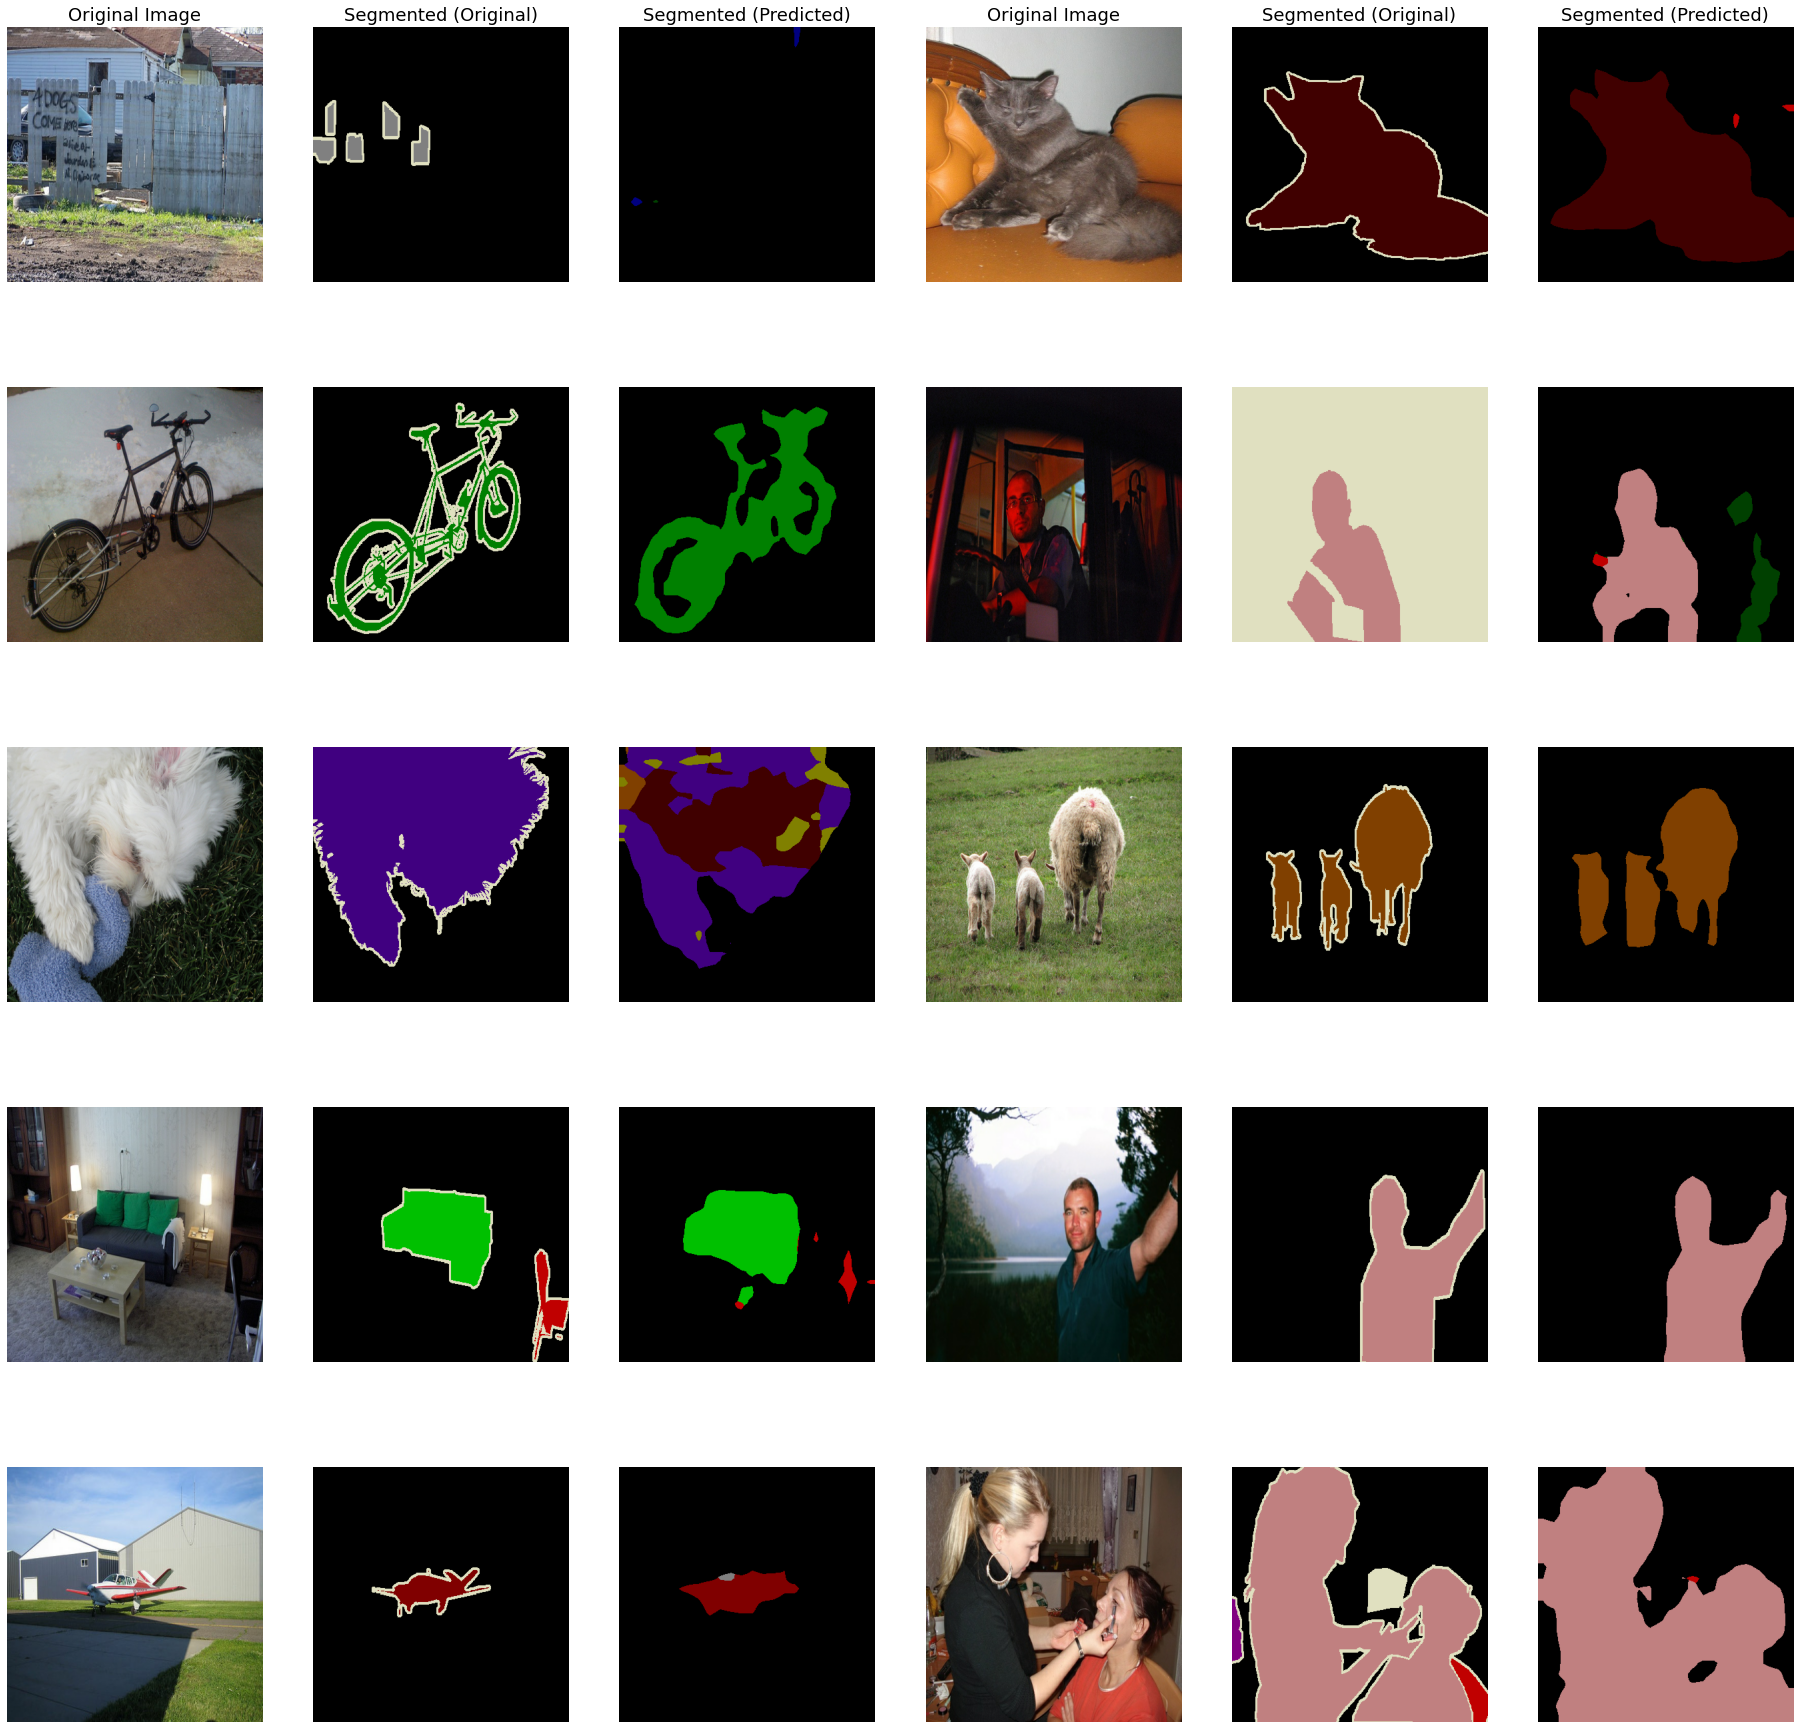

In [ ]:
test_image_ds = get_subset_tf_dataset(
    test_subset_fn, 1, 1,
    input_size=(384,384),
    shuffle=False)
n=10

generate_results_plot(test_image_ds, n, deeplabv3)

# Appendix B: U-Net model (with a pretrained encoder)

Here we're going to define a variant of the original U-net model discussed [here](https://arxiv.org/pdf/1505.04597.pdf). It consists of an encoder, which downsample the image using max pooling. Next a decoder, up samples (transpose convolution) the output gradually until it is large enough. In order to preserve local spatial information, the outputs of the interim encoder layers are copied and concatenated with the interim decoder layers.

## Why original u-net doesn't work for this problem?

if you have images / targets with original sizes proposed for original unet paper, the model won't learn. possible reasons,

* Pascal VOC data is more complex than what U-net was originally used for, requiring more parameters to learn from images

## Defining the data pipeline for U-Net

In [ ]:
batch_size = 8
epochs = 25


def get_steps_per_epoch(n_data, batch_size):
    """ Get steps for single epoch """
    if n_data % batch_size == 0:
        return n_data//batch_size
    else:
        return (n_data//batch_size)+1


# Defububg steps per training valid epoch
n_train = get_steps_per_epoch(
    len(pd.read_csv(os.path.join(subset_dir, "train.txt"), index_col=None, header=None, squeeze=True).tolist()),
    batch_size
)
n_valid = get_steps_per_epoch(
    len(pd.read_csv(os.path.join(subset_dir, "val.txt"), index_col=None, header=None, squeeze=True).tolist())//2,
    batch_size
)

print("Found {} training batches".format(n_train))
print("Found {} validation batches".format(n_valid))

# Defining data pipeline for train/valid/test
tr_image_ds = get_subset_tf_dataset(train_subset_fn, batch_size, epochs,
                                    input_size=(512, 512), output_size=(228,228), resize_to_before_crop=(572, 572),
                                    augmentation=True, shuffle=True)
val_image_ds = get_subset_tf_dataset(val_subset_fn, batch_size, epochs,
                                     input_size=(512, 512), output_size=(228,228), resize_to_before_crop=(572, 572),
                                     shuffle=False)
test_image_ds = get_subset_tf_dataset(test_subset_fn, batch_size, 1, input_size=(512, 512), output_size=(228,228), shuffle=False)

/tmp/ipykernel_8461/1469665136.py:15: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  len(pd.read_csv(os.path.join(subset_dir, "train.txt"), index_col=None, header=None, squeeze=True).tolist()),
/tmp/ipykernel_8461/1469665136.py:19: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  len(pd.read_csv(os.path.join(subset_dir, "val.txt"), index_col=None, header=None, squeeze=True).tolist())//2,


Found 183 training batches
Found 91 validation batches


## Define various layers of the U-Net model

In [ ]:
def downsample_layer(inp, filters, downsample=True, with_bn=True):
    """ Down sampling layer of the U-net """

    if downsample:
        # 2x2 Maxpooling layer
        inp = layers.MaxPooling2D((2,2), strides=(2,2))(inp)

    # 3x3 convolution layer
    conv1_out = layers.Conv2D(filters, (3,3), activation='relu', padding='same')(inp)
    if with_bn:
        conv1_out = layers.BatchNormalization()(conv1_out)

    # 3x3 convolution layer
    out = layers.Conv2D(filters, (3,3), activation='relu', padding='same')(conv1_out)
    if with_bn:
        out = layers.BatchNormalization()(out)

    return out

def upsample_conv(inp, copy_and_crop, filters):
    """ Up sampling layer of the U-net """

    # 2x2 transpose convolution layer
    conv1_out = layers.Conv2DTranspose(filters, (2,2), (2,2), activation='relu')(inp)
    # Size of the crop length for one side
    crop_side = int((copy_and_crop.shape[1]-conv1_out.shape[1])/2)

    # Crop if crop side is > 0
    if crop_side > 0:
        cropped_copy = layers.Cropping2D(crop_side)(copy_and_crop)
    else:
        cropped_copy = copy_and_crop

    # Concat the cropped encoder output and the decoder output
    concat_out = layers.Concatenate(axis=-1)([conv1_out, cropped_copy])

    # 3x3 convolution layer
    conv2_out = layers.Conv2D(filters, (3,3), activation='relu', padding='valid')(concat_out)

    # 3x3 Convolution layer
    out = layers.Conv2D(filters, (3,3), activation='relu', padding='valid')(conv2_out)

    return out



def decoder(inp, encoder):
    """ Define the decoder of the U-net model """

    up_1 = upsample_conv(inp, encoder.get_layer("conv3_block4_out").output, 512) # 32x32

    up_2 = upsample_conv(up_1, encoder.get_layer("conv2_block3_out").output, 256) # 64x64

    up_3 = upsample_conv(up_2, encoder.get_layer("conv1_relu").output, 64) # 128 x 128

    return up_3


def unet_pretrained_encoder():
    """ Define a pretrained encoder based on the Resnet50 model """

    # Defining an input layer of size 384x384x3
    inp = layers.Input(shape=(512, 512, 3))
    # Defining the pretrained resnet 50 as the encoder
    encoder = tf.keras.applications.ResNet50(
        include_top=False, input_tensor=inp,pooling=None
    )

    # Encoder output # 8x8
    decoder_out = decoder(encoder.get_layer("conv4_block6_out").output, encoder)

    # Final output of the model (note no activation)
    final_out = layers.Conv2D(num_classes, (1,1))(decoder_out)
    # Final model
    unet = models.Model(encoder.input, final_out)
    return unet





# Define and compile the full model

In [ ]:
K.clear_session()

# Define the model
unet = unet_pretrained_encoder()

# Defining the optimizer and metrics
optimizer = tf.keras.optimizers.Adam(lr=0.0001)
unet.compile(
    loss=ce_dice_loss_from_logits(num_classes),
    optimizer=optimizer,
    metrics=[
        MeanIoUMetric(num_classes),
        MeanAccuracyMetric(num_classes),
        PixelAccuracyMetric(num_classes)
    ])

# Summary of the model
unet.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 518, 518, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 256, 256, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

 conv2_block2_add (Add)         (None, 128, 128, 25  0           ['conv2_block1_out[0][0]',       
                                6)                                'conv2_block2_3_bn[0][0]']      
                                                                                                  
 conv2_block2_out (Activation)  (None, 128, 128, 25  0           ['conv2_block2_add[0][0]']       
                                6)                                                                
                                                                                                  
 conv2_block3_1_conv (Conv2D)   (None, 128, 128, 64  16448       ['conv2_block2_out[0][0]']       
                                )                                                                 
                                                                                                  
 conv2_block3_1_bn (BatchNormal  (None, 128, 128, 64  256        ['conv2_block3_1_conv[0][0]']    
 ization) 

 conv3_block2_3_conv (Conv2D)   (None, 64, 64, 512)  66048       ['conv3_block2_2_relu[0][0]']    
                                                                                                  
 conv3_block2_3_bn (BatchNormal  (None, 64, 64, 512)  2048       ['conv3_block2_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block2_add (Add)         (None, 64, 64, 512)  0           ['conv3_block1_out[0][0]',       
                                                                  'conv3_block2_3_bn[0][0]']      
                                                                                                  
 conv3_block2_out (Activation)  (None, 64, 64, 512)  0           ['conv3_block2_add[0][0]']       
                                                                                                  
 conv3_blo

                                                                                                  
 conv4_block1_0_bn (BatchNormal  (None, 32, 32, 1024  4096       ['conv4_block1_0_conv[0][0]']    
 ization)                       )                                                                 
                                                                                                  
 conv4_block1_3_bn (BatchNormal  (None, 32, 32, 1024  4096       ['conv4_block1_3_conv[0][0]']    
 ization)                       )                                                                 
                                                                                                  
 conv4_block1_add (Add)         (None, 32, 32, 1024  0           ['conv4_block1_0_bn[0][0]',      
                                )                                 'conv4_block1_3_bn[0][0]']      
                                                                                                  
 conv4_blo

 n)                                                                                               
                                                                                                  
 conv4_block4_3_conv (Conv2D)   (None, 32, 32, 1024  263168      ['conv4_block4_2_relu[0][0]']    
                                )                                                                 
                                                                                                  
 conv4_block4_3_bn (BatchNormal  (None, 32, 32, 1024  4096       ['conv4_block4_3_conv[0][0]']    
 ization)                       )                                                                 
                                                                                                  
 conv4_block4_add (Add)         (None, 32, 32, 1024  0           ['conv4_block3_out[0][0]',       
                                )                                 'conv4_block4_3_bn[0][0]']      
          

 cropping2d (Cropping2D)        (None, 120, 120, 25  0           ['conv2_block3_out[0][0]']       
                                6)                                                                
                                                                                                  
 concatenate_1 (Concatenate)    (None, 120, 120, 51  0           ['conv2d_transpose_1[0][0]',     
                                2)                                'cropping2d[0][0]']             
                                                                                                  
 conv2d_2 (Conv2D)              (None, 118, 118, 25  1179904     ['concatenate_1[0][0]']          
                                6)                                                                
                                                                                                  
 conv2d_3 (Conv2D)              (None, 116, 116, 25  590080      ['conv2d_2[0][0]']               
          

## Training the U-Net model

In [ ]:
if not os.path.exists('eval'):
    os.mkdir('eval')

# Logging the performance metrics to a CSV file
csv_logger = tf.keras.callbacks.CSVLogger(os.path.join('eval','1_pretrained_unet.log'))

monitor_metric = 'val_loss'
mode = 'min' if 'loss' in monitor_metric else 'max'
print("Using metric={} and mode={} for EarlyStopping".format(monitor_metric, mode))
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor=monitor_metric, factor=0.1, patience=3, mode=mode, min_lr=1e-8
)
# EarlyStopping itself increases the memory requirement
# restore_best_weights will increase the memory req for large models
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor=monitor_metric, patience=6, mode=mode, restore_best_weights=False
)

t1 = time.time()

# Train the model
unet.fit(
    tr_image_ds, steps_per_epoch=n_train,
    validation_data=val_image_ds, validation_steps=n_valid,
    epochs=epochs, callbacks=[lr_callback, csv_logger])
t2 = time.time()

print("It took {} seconds to complete the training".format(t2-t1))